In [2]:
from google.colab import files
uploaded = files.upload()


Saving Online Retail.xlsx to Online Retail.xlsx


In [3]:
# I am importing basic packages, visualisation and modeling tools
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Ignore warnings for a cleaner output and a neater appearence
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Loading the dataset
df = pd.read_excel('Online Retail.xlsx')

# Using DF to look at the first few rows as a sample
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
# Checking the structure so I can understand the data better before working with it
df.info()
df.describe()
print("Dataset Overview:")
df.info()
print("\nFirst few rows:")
print(df.head())
print("\nBasic statistics:")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB
Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-n

In [6]:
# Data Cleaning in order to fix messy, incorrect, or incomplete data before analyzing it. The results will be more accurate
print("DATA CLEANING")
print(f"Original dataset: {len(df)} rows")

# Removing the missing Customer IDs
df = df[pd.notnull(df['CustomerID'])]

# Removing negative quantities (returns)
df = df[df['Quantity'] > 0]

# Creating total spend column
df['TotalSpend'] = df['Quantity'] * df['UnitPrice']

# Converting InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

DATA CLEANING
Original dataset: 541909 rows


In [9]:
# Reference date (the day after last transaction)
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Group by customer
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'count',  # Frequency
    'TotalSpend': 'sum'  # Monetary
})

# Renaming columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']
print("\nRFM metrics created:")
print(rfm.head())
print(f"\nTotal customers: {len(rfm)}")

# Checking for extreme values
print("RFM Statistics:")
print(rfm.describe())

# Create summary statistics to get an overview
summary_stats = pd.DataFrame({
    'Metric': ['Recency (days)', 'Frequency (orders)', 'Monetary (£)'],
    'Mean': [
        rfm['Recency'].mean(),
        rfm['Frequency'].mean(),
        rfm['Monetary'].mean()
    ],
    'Median': [
        rfm['Recency'].median(),
        rfm['Frequency'].median(),
        rfm['Monetary'].median()
    ],
    'Std Dev': [
        rfm['Recency'].std(),
        rfm['Frequency'].std(),
        rfm['Monetary'].std()
    ],
    'Min': [
        rfm['Recency'].min(),
        rfm['Frequency'].min(),
        rfm['Monetary'].min()
    ],
    'Max': [
        rfm['Recency'].max(),
        rfm['Frequency'].max(),
        rfm['Monetary'].max()
    ]
})

# Round to 1 decimal place
summary_stats = summary_stats.round(1)

print("\nRFM Summary Statistics:")
print(summary_stats.to_string(index=False))


RFM metrics created:
            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1  77183.60
12347.0           2        182   4310.00
12348.0          75         31   1797.24
12349.0          19         73   1757.55
12350.0         310         17    334.40

Total customers: 4339
RFM Statistics:
           Recency    Frequency       Monetary
count  4339.000000  4339.000000    4339.000000
mean     92.518322    91.708689    2053.793018
std     100.009747   228.792852    8988.248381
min       1.000000     1.000000       0.000000
25%      18.000000    17.000000     307.245000
50%      51.000000    41.000000     674.450000
75%     142.000000   100.000000    1661.640000
max     374.000000  7847.000000  280206.020000

RFM Summary Statistics:
            Metric   Mean  Median  Std Dev  Min      Max
    Recency (days)   92.5    51.0    100.0  1.0    374.0
Frequency (orders)   91.7    41.0    228.8  1.0   7847.0
      Monetary (£) 2053.8   674.4

In [10]:
# Reference date (the day after last transaction)
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Group by customer
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'count',  # Frequency
    'TotalSpend': 'sum'  # Monetary
})

# Renaming columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']
print("\nRFM metrics created:")
print(rfm.head())
print(f"\nTotal customers: {len(rfm)}")

# Checking for extreme values
print("RFM Statistics:")
print(rfm.describe())


RFM metrics created:
            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1  77183.60
12347.0           2        182   4310.00
12348.0          75         31   1797.24
12349.0          19         73   1757.55
12350.0         310         17    334.40

Total customers: 4339
RFM Statistics:
           Recency    Frequency       Monetary
count  4339.000000  4339.000000    4339.000000
mean     92.518322    91.708689    2053.793018
std     100.009747   228.792852    8988.248381
min       1.000000     1.000000       0.000000
25%      18.000000    17.000000     307.245000
50%      51.000000    41.000000     674.450000
75%     142.000000   100.000000    1661.640000
max     374.000000  7847.000000  280206.020000


In [11]:
# Identifing potential outliers, this will help understand the data and any issues in order to mitigate them
print(" OUTLIER ANALYSIS ")
Q1 = rfm['Monetary'].quantile(0.25)
Q3 = rfm['Monetary'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 3 * IQR  # Using 3*IQR for extreme outliers
extreme_outliers = rfm[rfm['Monetary'] > upper_bound]
print(f"Found {len(extreme_outliers)} extreme outliers in Monetary (>{upper_bound:.2f})")
print("Top 5 highest spenders:")
print(rfm.nlargest(5, 'Monetary'))

 OUTLIER ANALYSIS 
Found 222 extreme outliers in Monetary (>5724.82)
Top 5 highest spenders:
            Recency  Frequency   Monetary
CustomerID                               
14646.0           2       2080  280206.02
18102.0           1        431  259657.30
17450.0           8        337  194550.79
16446.0           1          3  168472.50
14911.0           1       5677  143825.06


In [12]:
# Preparing data for K-Means
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

Inertia list length: 9
Silhouette scores list length: 9
Inertia values: [9423.534822243337, 5452.6497583594255, 4933.306249701903, 3516.6572990518052, 2501.1543868767794, 1923.4034556842007, 1762.5574213569191, 1512.960595993029, 1344.1201350311403]
Silhouette scores: [np.float64(0.5766409959487967), np.float64(0.6020142101419289), np.float64(0.3582820982995069), np.float64(0.3599623303396918), np.float64(0.5134323008254977), np.float64(0.5226122702435979), np.float64(0.5244772992267944), np.float64(0.5046758265551248), np.float64(0.42713929913001414)]


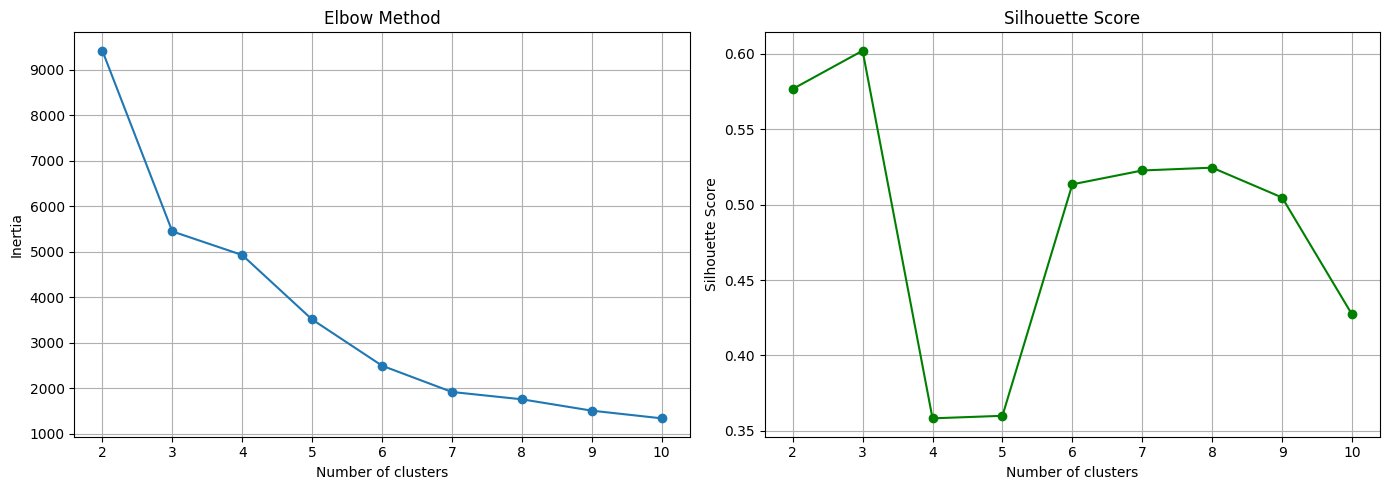

In [13]:
# Finding the Optimal Number of Clusters (Elbow method)
inertia = []
silhouette_scores = []
for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(rfm_scaled)
    inertia.append(model.inertia_)
    labels = model.predict(rfm_scaled)
    silhouette_scores.append(silhouette_score(rfm_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot. It shows how well customers fit into groups as you increase the number of groups.
ax1.plot(range(2, 11), inertia, marker='o')
ax1.set_title('Elbow Method')
ax1.set_xlabel('Number of clusters')
ax1.set_ylabel('Inertia')
ax1.grid(True)

print(f"Inertia list length: {len(inertia)}")
print(f"Silhouette scores list length: {len(silhouette_scores)}")
print(f"Inertia values: {inertia}")
print(f"Silhouette scores: {silhouette_scores}")

# Silhouette plot. It shows how well-separated are the clusters in the data.
ax2.plot(range(2, 11), silhouette_scores, marker='o', color='green')
ax2.set_title('Silhouette Score')
ax2.set_xlabel('Number of clusters')
ax2.set_ylabel('Silhouette Score')
ax2.grid(True)

plt.tight_layout()
plt.show()


In [14]:
# Print scores to help decide whiich cluster to use
print("\nSilhouette scores by k:")
for k, score in zip(range(2, 11), silhouette_scores):
    print(f"k={k}: {score:.4f}")

kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Cluster size analysis
cluster_counts = rfm['Cluster'].value_counts().sort_index()
print("Number of customers per cluster:")
print(cluster_counts)
print("\nPercentage distribution:")
print((cluster_counts / len(rfm) * 100).round(2))

# Checking for tiny clusters
tiny_clusters = cluster_counts[cluster_counts < 50]
if len(tiny_clusters) > 0:
    print(f"\nClusters with fewer than 50 customers:")
    print(tiny_clusters)
    print("These may represent outliers or special segments that need investigation.")


Silhouette scores by k:
k=2: 0.5766
k=3: 0.6020
k=4: 0.3583
k=5: 0.3600
k=6: 0.5134
k=7: 0.5226
k=8: 0.5245
k=9: 0.5047
k=10: 0.4271
Number of customers per cluster:
Cluster
0    2165
1    1331
2      13
3     830
Name: count, dtype: int64

Percentage distribution:
Cluster
0    49.90
1    30.68
2     0.30
3    19.13
Name: count, dtype: float64

Clusters with fewer than 50 customers:
Cluster
2    13
Name: count, dtype: int64
These may represent outliers or special segments that need investigation.


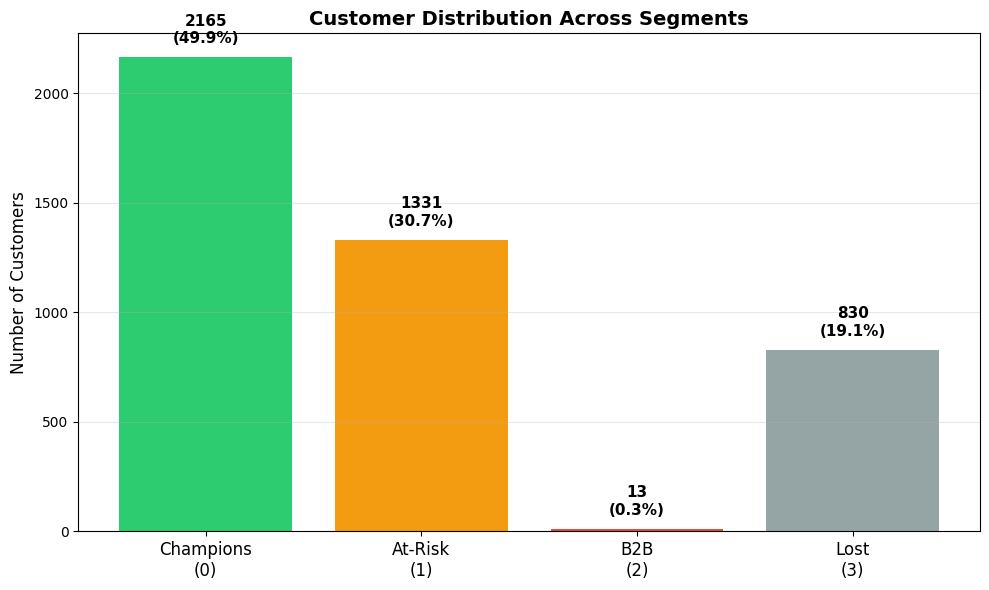

In [15]:
import matplotlib.pyplot as plt

cluster_counts = rfm['Cluster'].value_counts().sort_index()
cluster_labels = ['Champions\n(0)', 'At-Risk\n(1)', 'B2B\n(2)', 'Lost\n(3)']

plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(cluster_counts)), cluster_counts.values,
               color=['#2ecc71', '#f39c12', '#e74c3c', '#95a5a6'])

# Add value labels on bars
for i, (bar, count) in enumerate(zip(bars, cluster_counts.values)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{count}\n({count/len(rfm)*100:.1f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xticks(range(len(cluster_counts)), cluster_labels, fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.title('Customer Distribution Across Segments', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('cluster_distribution.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

            Recency           Frequency               Monetary              \
               mean median         mean  median           mean      median   
Cluster                                                                      
0         20.886374   18.0   135.476212    87.0    2648.875746    1328.550   
1         97.846732   86.0    37.891811    27.0     777.692744     489.310   
2          4.692308    2.0  2566.000000  1818.0  126118.310000  117379.630   
3        272.196386  266.0    25.091566    17.0     604.752820     303.335   

               
        count  
Cluster        
0        2165  
1        1331  
2          13  
3         830  


<function matplotlib.pyplot.show(close=None, block=None)>

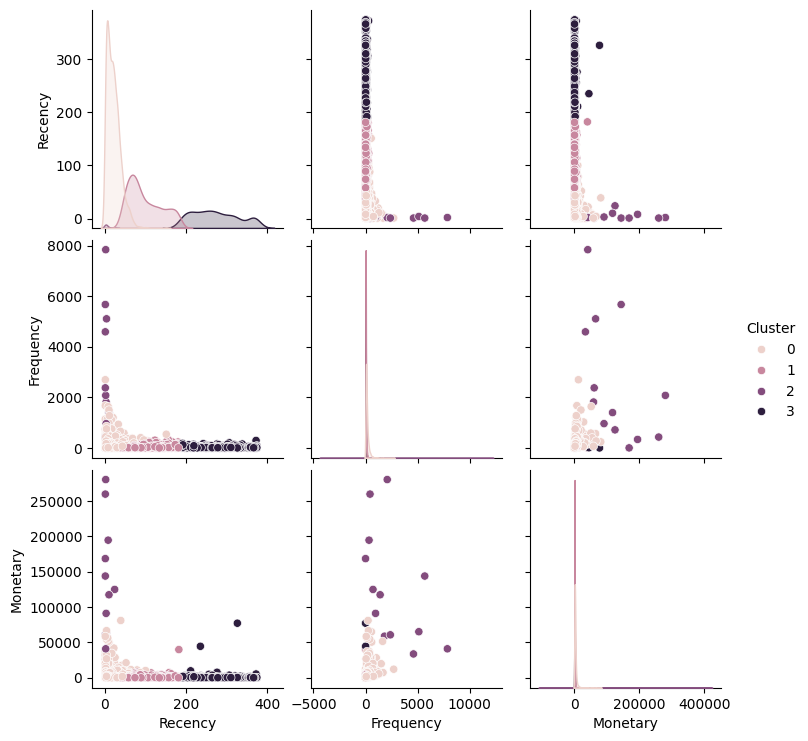

In [16]:
# Cluster averages
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': ['mean', 'median'],
    'Frequency': ['mean', 'median'],
    'Monetary': ['mean', 'median', 'count']
})
print(cluster_summary)

# Visualising
sns.pairplot(rfm, hue='Cluster')
plt.show

In [17]:
rfm.groupby('Cluster').agg({
    'Recency': ['mean', 'median'],
    'Frequency': ['mean', 'median'],
    'Monetary': ['mean', 'median', 'count']
})


Recency           Frequency               Monetary              \
               mean median         mean  median           mean      median   
Cluster                                                                      
0         20.886374   18.0   135.476212    87.0    2648.875746    1328.550   
1         97.846732   86.0    37.891811    27.0     777.692744     489.310   
2          4.692308    2.0  2566.000000  1818.0  126118.310000  117379.630   
3        272.196386  266.0    25.091566    17.0     604.752820     303.335   

               
        count  
Cluster        
0        2165  
1        1331  
2          13  
3         830

 VISUALIZING CLUSTERS 


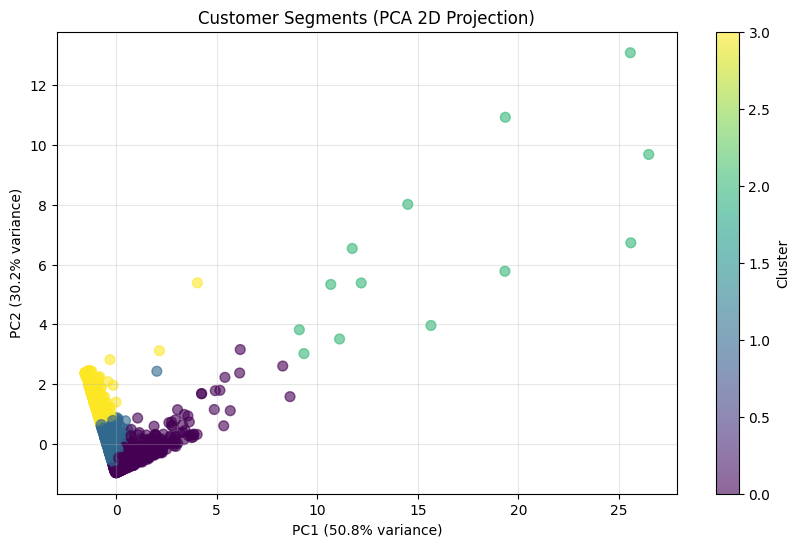

<Figure size 800x500 with 0 Axes>

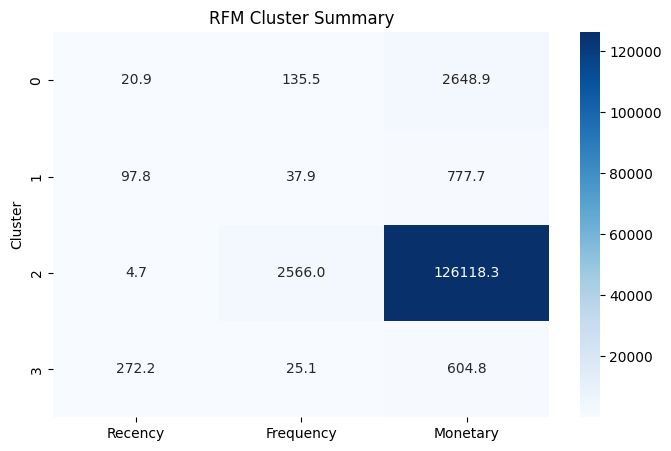

In [18]:
# 2D Visualization using PCA (PCA is a technique to simplify complex data while keeping the most important information.)
print(" VISUALIZING CLUSTERS ")
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(rfm_pca[:, 0], rfm_pca[:, 1],
                     c=rfm['Cluster'], cmap='viridis',
                     alpha=0.6, s=50)
plt.colorbar(scatter, label='Cluster')
plt.title('Customer Segments (PCA 2D Projection)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.grid(True, alpha=0.3)
plt.show()

# Heatmap (A heatmap is a visual representation of numbers using colors.)
plt.figure(figsize=(8,5))
plt.figure(figsize=(8, 5))
cluster_means = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
sns.heatmap(cluster_means, annot=True, fmt=".1f", cmap="Blues")
plt.title("RFM Cluster Summary")
plt.show()

In [19]:
# Detailed cluster interpretation
for cluster_id in sorted(rfm['Cluster'].unique()):
    cluster_data = rfm[rfm['Cluster'] == cluster_id]
    print(f"\n--- Cluster {cluster_id} ---")
    print(f"Size: {len(cluster_data)} customers ({len(cluster_data)/len(rfm)*100:.1f}%)")
    print(f"Avg Recency: {cluster_data['Recency'].mean():.1f} days")
    print(f"Avg Frequency: {cluster_data['Frequency'].mean():.1f} purchases")
    print(f"Avg Monetary: ${cluster_data['Monetary'].mean():.2f}")

# Business interpretation
recency = cluster_data['Recency'].mean()
frequency = cluster_data['Frequency'].mean()
monetary = cluster_data['Monetary'].mean()

if recency < 50 and frequency > 100 and monetary > 2000:
        print("Interpretation: VIP/Champions - Recent, frequent, high-value customers")
elif recency < 50 and frequency > 30:
        print("Interpretation: Loyal Customers - Recent and frequent buyers")
elif recency > 200:
        print("Interpretation: At-Risk/Lost - Haven't purchased recently")
elif monetary > 10000:
        print("Interpretation: Big Spenders - High monetary value (possibly B2B)")
else:
        print("Interpretation: Regular Customers - Moderate engagement")



--- Cluster 0 ---
Size: 2165 customers (49.9%)
Avg Recency: 20.9 days
Avg Frequency: 135.5 purchases
Avg Monetary: $2648.88

--- Cluster 1 ---
Size: 1331 customers (30.7%)
Avg Recency: 97.8 days
Avg Frequency: 37.9 purchases
Avg Monetary: $777.69

--- Cluster 2 ---
Size: 13 customers (0.3%)
Avg Recency: 4.7 days
Avg Frequency: 2566.0 purchases
Avg Monetary: $126118.31

--- Cluster 3 ---
Size: 830 customers (19.1%)
Avg Recency: 272.2 days
Avg Frequency: 25.1 purchases
Avg Monetary: $604.75
Interpretation: At-Risk/Lost - Haven't purchased recently


In [20]:
# Investigate Cluster 2
cluster_2_customers = rfm[rfm['Cluster'] == 2]
print(cluster_2_customers)

# Look at their actual transactions
cluster_2_ids = cluster_2_customers.index.tolist()
cluster_2_transactions = df[df['CustomerID'].isin(cluster_2_ids)]

print("\nTotal transactions for these 13 customers:")
print(cluster_2_transactions.groupby('CustomerID').agg({
    'InvoiceNo': 'count',
    'TotalSpend': 'sum',
    'Description': lambda x: x.value_counts().head(3)
}))

            Recency  Frequency   Monetary  Cluster
CustomerID                                        
12415.0          24        716  124914.53        2
12748.0           1       4596   33719.73        2
13089.0           3       1818   58825.83        2
14096.0           4       5111   65164.79        2
14156.0          10       1400  117379.63        2
14646.0           2       2080  280206.02        2
14911.0           1       5677  143825.06        2
15311.0           1       2379   60767.90        2
16446.0           1          3  168472.50        2
17450.0           8        337  194550.79        2
17511.0           3        963   91062.38        2
17841.0           2       7847   40991.57        2
18102.0           1        431  259657.30        2

Total transactions for these 13 customers:
            InvoiceNo  TotalSpend   Description
CustomerID                                     
12415.0           716   124914.53     [6, 6, 6]
12748.0          4596    33719.73  [33, 17, 16]